6a) Write the Python function ‘naive_matrix_multiplication(A, B)‘ that uses three nested ‘for‘ loops to
compute the product of two NumPy arrays ‘A‘ and ‘B‘.

In [2]:
import numpy as np

def naive_matrix_multiplication(A: np.array, B: np.array):
    M, N1 = A.shape
    N2, P = B.shape

    if N1 != N2:
        print( "Invalid matrix multiplication")
        return
    
    N = N1

    C = np.zeros((M, P))

    for row_idx in range(M):
        for col_idx in range(P):
            running_sum = 0.0
            for element_idx in range(N):
                running_sum += A[row_idx][element_idx] * B[element_idx][col_idx]
            C[row_idx][col_idx] = running_sum
    
    return C

    

6b) We want to analyze how the execution time scales with dimension.
• Define a list of dimensions n ↓ { 10, 20, 40, 80, 160 } .

• For each n, create two random square matrices A, B of size n → n.
• Measure the execution time of your naive function.
• Measure the execution time of NumPy’s ‘np.dot(A, B)‘.

In [3]:
import timeit
n = [10, 20, 40, 80, 160]

execution_times_naive = {dim: 0.0 for dim in n}
execution_times_numpy_optimized = {dim: 0.0 for dim in n}

for dim in n:
    A = np.random.randn(dim, dim)
    B = np.random.randn(dim, dim)

    execution_times_naive[dim] = timeit.timeit(lambda: naive_matrix_multiplication(A, B), number=1)
    execution_times_numpy_optimized[dim] = timeit.timeit(lambda: A @ B, number=1)

print("Execution times for naive implementation")
print(execution_times_naive)
print("Execution times for optimized numpy matrix multiplication")
print(execution_times_numpy_optimized)

Execution times for naive implementation
{10: 0.0011599999997997656, 20: 0.006528500001877546, 40: 0.054636600005324, 80: 0.4054742000007536, 160: 3.2075583999976516}
Execution times for optimized numpy matrix multiplication
{10: 0.0017389999993611127, 20: 3.789999755099416e-05, 40: 0.0001615999935893342, 80: 0.00137489999178797, 160: 0.0005942999996477738}


6c) Generate a plot comparing the two implementations.

Plot saved as 'matmul_scaling.png'


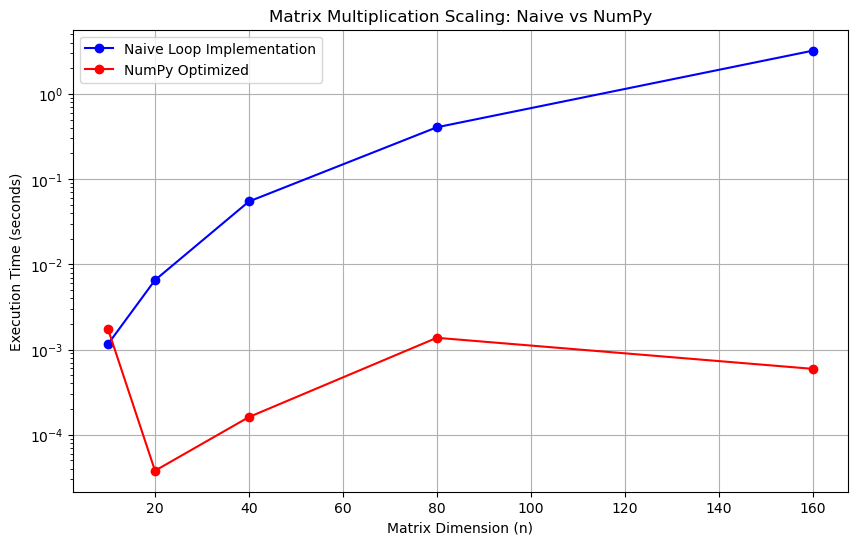

In [7]:
import matplotlib.pyplot as plt

dimensions = n
naive_times = list(execution_times_naive.values())
numpy_times = list(execution_times_numpy_optimized.values())

# Plotting the scaling results
plt.figure(figsize=(10, 6))

# Plot Naive times
plt.plot(dimensions, naive_times, 'bo-', label='Naive Loop Implementation')

# Plot NumPy times
plt.plot(dimensions, numpy_times, 'ro-', label='NumPy Optimized')

plt.xlabel("Matrix Dimension (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Matrix Multiplication Scaling: Naive vs NumPy")
plt.legend()
plt.grid(True)
plt.yscale('log')  # Log scale is necessary to see both curves clearly

plt.savefig('matmul_scaling.png', bbox_inches='tight')
print("Plot saved as 'matmul_scaling.png'")

plt.show()

Question 7: (Coding: The Real Cost of Associativity - 20 pts). While matrix multiplication is associative
mathematically ( ( AB ) C = A ( BC ) ), the order of operations significantly impacts the actual execution
time on a computer. In this problem, you will generate actual matrices and measure the wall-clock time
difference between efficient and inefficient multiplication orders.
Consider a chain of four matrices A, B, C, D. We define a "base" set of dimensions:
• A : 50 → 20
• B : 20 → 300
• C : 300 → 10
• D : 10 → 100

7a) Write a Python script that introduces a scaling factor S. We will vary S from 11 to 20 (or higher if
your machine is fast). For a given S, the dimensions of the matrices are scaled by S.

In [9]:

scaling_factors = [sf for sf in range(11, 21)]

matrix_dimensions = [(50, 20), (20, 300), (300, 10), (10, 100)]

scaled_matrix_dimensions: dict[int, list[tuple]] = {}
for scaling_factor in scaling_factors:
    scaled_matrix_dimensions[scaling_factor] = []
    for dim_rows, dim_cols in matrix_dimensions:
        scaled_matrix_dimensions[scaling_factor].append((dim_rows * scaling_factor, dim_cols * scaling_factor))

print(scaled_matrix_dimensions)

{11: [(550, 220), (220, 3300), (3300, 110), (110, 1100)], 12: [(600, 240), (240, 3600), (3600, 120), (120, 1200)], 13: [(650, 260), (260, 3900), (3900, 130), (130, 1300)], 14: [(700, 280), (280, 4200), (4200, 140), (140, 1400)], 15: [(750, 300), (300, 4500), (4500, 150), (150, 1500)], 16: [(800, 320), (320, 4800), (4800, 160), (160, 1600)], 17: [(850, 340), (340, 5100), (5100, 170), (170, 1700)], 18: [(900, 360), (360, 5400), (5400, 180), (180, 1800)], 19: [(950, 380), (380, 5700), (5700, 190), (190, 1900)], 20: [(1000, 400), (400, 6000), (6000, 200), (200, 2000)]}


7b) Inside a loop over S, generate random NumPy matrices A, B, C, D with the scaled dimensions.

In [11]:
scaling_factor_to_numpy_matrices: dict[int, dict[str, np.array]] = {}

for scaling_factor in scaling_factors:
    scaling_factor_to_numpy_matrices[scaling_factor] = {}
    for matrix_name, matrix_dim in zip(['A', 'B', 'C', 'D'], scaled_matrix_dimensions[scaling_factor]):
        dim_x, dim_y = matrix_dim
        scaling_factor_to_numpy_matrices[scaling_factor][matrix_name] = np.random.randn(dim_x, dim_y)

print(scaling_factor_to_numpy_matrices)


{11: {'A': array([[ 0.44060596, -1.90791449,  0.93217746, ...,  1.00981667,
        -0.23013344,  0.12094265],
       [-0.66265715,  1.35220543, -0.94131596, ..., -0.72984089,
        -1.3941426 , -0.13855919],
       [-1.68757119,  1.5138136 , -0.24203316, ...,  0.39719091,
        -1.21397359,  0.32518828],
       ...,
       [-0.53953029,  0.87219051,  0.59772581, ..., -0.86741917,
         0.46298409,  0.47788215],
       [ 1.08569212, -0.69247245, -0.65855963, ..., -0.54936579,
        -1.01447346,  2.16036552],
       [ 0.79934628, -0.19427136, -0.60133599, ..., -1.22299605,
        -0.71394095, -1.51889508]]), 'B': array([[-0.35672436, -0.1746183 , -1.22992225, ...,  0.46957996,
         0.31012037, -0.24912561],
       [-0.71841999,  0.52768608,  1.36632588, ...,  0.46591851,
        -1.17434894,  1.07236083],
       [ 0.17141376, -1.00701009,  1.06961426, ...,  2.24336822,
         0.57695312, -1.6031559 ],
       ...,
       [ 1.11504294,  0.03265085,  1.54582171, ...,  0.556

7c) Measure the execution time for the following three specific parenthesizations:
(a) Strategy 1 (Default Left-to-Right): R1 = ((AB)C)D
(b) Strategy 2 (Optimal theoretical path): R2 = (A(BC))D
(c) Strategy 3 (Inefficient path): R3 = (AB)(CD)
Note: You must use parentheses in Python to force the order, e.g., (A @ B) @ (C @ D).

In [14]:
from collections import defaultdict
parenthesizations_to_execution_times:dict[str, dict[int, float]] = defaultdict(dict)
for scaling_factor in scaling_factors:
    A = scaling_factor_to_numpy_matrices[scaling_factor]['A']
    B = scaling_factor_to_numpy_matrices[scaling_factor]['B']
    C = scaling_factor_to_numpy_matrices[scaling_factor]['C']
    D = scaling_factor_to_numpy_matrices[scaling_factor]['D']
    parenthesizations_to_execution_times["((AB)C)D"][scaling_factor] = timeit.timeit(lambda: ((A@B)@C)@D, number = 1)
    parenthesizations_to_execution_times["(A(BC))D"][scaling_factor] = timeit.timeit(lambda: (A @ (B @ C))@D, number=1)
    parenthesizations_to_execution_times["(AB)(CD)"][scaling_factor] = timeit.timeit(lambda: (A @ B) @ (C @ D), number=1)

7d) Generate a plot comparing the execution times.

Plot saved as 'associativity_time.png'


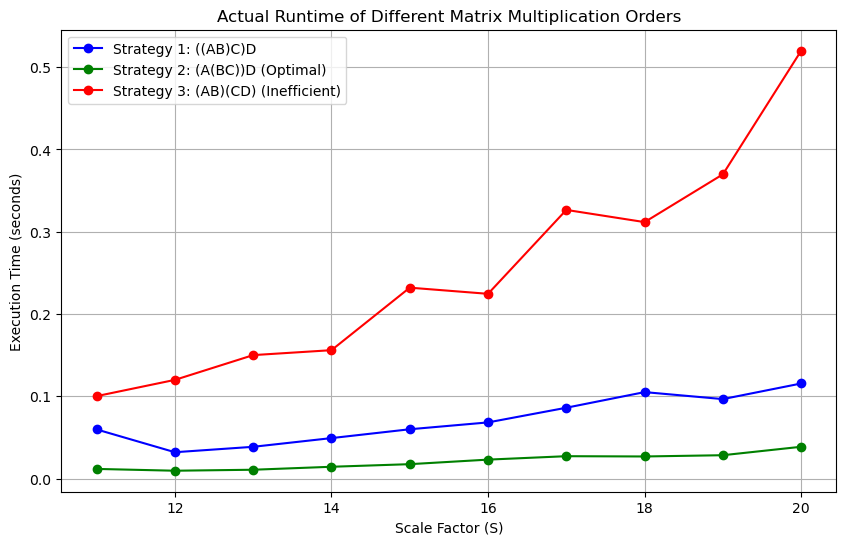

In [15]:
# Plotting the Time Analysis
import matplotlib.pyplot as plt
scales = scaling_factors 
times_strategy_1 = list(parenthesizations_to_execution_times["((AB)C)D"].values())
times_strategy_2 = list(parenthesizations_to_execution_times["(A(BC))D"].values())
times_strategy_3 = list(parenthesizations_to_execution_times["(AB)(CD)"].values())
plt.figure(figsize=(10, 6))

plt.plot(scales, times_strategy_1, 'bo-', 
         label='Strategy 1: ((AB)C)D')

plt.plot(scales, times_strategy_2, 'go-', 
         label='Strategy 2: (A(BC))D (Optimal)')

plt.plot(scales, times_strategy_3, 'ro-', 
         label='Strategy 3: (AB)(CD) (Inefficient)')

plt.xlabel("Scale Factor (S)")
plt.ylabel("Execution Time (seconds)")
plt.title("Actual Runtime of Different Matrix Multiplication Orders")

plt.legend()
plt.grid(True)

plt.savefig('associativity_time.png', bbox_inches='tight')
print("Plot saved as 'associativity_time.png'")

plt.show()